<a href="https://colab.research.google.com/github/Gowtham13042007/cron_job/blob/main/convolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D,Dropout
from tensorflow.keras.optimizers import RMSprop

In [ ]:
(mnist_train_images,mnist_train_labels),(mnist_test_images,mnist_test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
mnist_train_images.shape

(60000, 28, 28)

In [ ]:
train_labels=tensorflow.keras.utils.to_categorical(mnist_train_labels,10)
test_labels=tensorflow.keras.utils.to_categorical(mnist_test_labels,10)

In [ ]:
from tensorflow.keras import backend as K

if K.image_data_format()=='channels_first':
  train_images=mnist_train_images.reshape(mnist_train_images.shape[0],1,28,28)  # number_of_images channels height width
  test_images=mnist_test_images.reshape(mnist_test_images.shape[0],1,28,28)
  input_shape=(1,28,28)
else:
  train_images=mnist_train_images.reshape(mnist_train_images.shape[0],28,28,1) # number_of_images height width channels
  test_images=mnist_test_images.reshape(mnist_test_images.shape[0],28,28,1)
  input_shape=(28,28,1)


[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


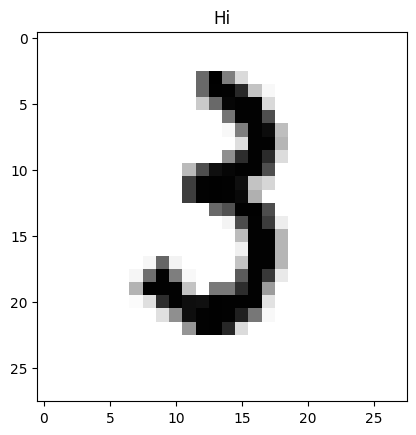

In [ ]:
import matplotlib.pyplot as plt

def display_sample(num):
  print(train_labels[num])
  label=train_labels[num].argmax(axis=0)
  image=train_images[num].reshape(28,28)
  plt.title('Hi')
  plt.imshow(image,cmap=plt.get_cmap('gray_r'))
  plt.show()

display_sample(1234)

In [ ]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=input_shape)) # kernel size detects the edges,curves,corners etc
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()  #1st (28-3+1,28-3+1,32)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])


In [ ]:
history=model.fit(train_images,train_labels,batch_size=32,epochs=10,verbose=2,validation_data=(test_images,test_labels))

Epoch 1/10
1875/1875 - 171s - 91ms/step - accuracy: 0.9076 - loss: 0.4436 - val_accuracy: 0.9798 - val_loss: 0.0625
Epoch 2/10
1875/1875 - 170s - 91ms/step - accuracy: 0.9589 - loss: 0.1399 - val_accuracy: 0.9813 - val_loss: 0.0561
Epoch 3/10
1875/1875 - 198s - 105ms/step - accuracy: 0.9680 - loss: 0.1132 - val_accuracy: 0.9817 - val_loss: 0.0621
Epoch 4/10
1875/1875 - 203s - 108ms/step - accuracy: 0.9721 - loss: 0.0947 - val_accuracy: 0.9858 - val_loss: 0.0448
Epoch 5/10
1875/1875 - 200s - 107ms/step - accuracy: 0.9766 - loss: 0.0800 - val_accuracy: 0.9870 - val_loss: 0.0471
Epoch 6/10
1875/1875 - 167s - 89ms/step - accuracy: 0.9784 - loss: 0.0765 - val_accuracy: 0.9875 - val_loss: 0.0432
Epoch 7/10
1875/1875 - 205s - 109ms/step - accuracy: 0.9813 - loss: 0.0639 - val_accuracy: 0.9885 - val_loss: 0.0392
Epoch 8/10
1875/1875 - 166s - 89ms/step - accuracy: 0.9812 - loss: 0.0628 - val_accuracy: 0.9899 - val_loss: 0.0368
Epoch 9/10
1875/1875 - 166s - 89ms/step - accuracy: 0.9828 - loss: 0

In [ ]:
score=model.evaluate(test_images,test_labels,verbose=0)
print('Test loss:',score[0])
print('Test accuracy:',score[1])